Import the libraries

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import holidays
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import joblib
import os
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

##### Load the Feature-Engineered Dataset

In [89]:
df = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\Model_Dataset\Hospital_Bed_Demand_Feature_Engineered.csv")
df.head()

,hospital_id,datetime,ward,occupied_beds,staffed_beds,occupancy_rate,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7,day_of_week,month,quarter,week_of_year,is_weekend,is_public_holiday,avg_los,median_los,max_los
0,HHN-BIR-01,2024-01-08,ICU,8.916667,8.916667,1.000000,8.958333,6.291667,2.041667,6.261905,1.903444,0,1,1,2,0,0,60.633333,60.90,66.1
1,HHN-BIR-01,2024-01-09,ICU,8.916667,8.916667,1.000000,8.916667,8.958333,4.583333,6.880952,1.970034,1,1,1,2,0,0,23.100000,23.10,23.1
2,HHN-BIR-01,2024-01-10,ICU,8.791667,8.791667,1.000000,8.916667,8.916667,4.916667,7.434524,1.867866,2,1,1,2,0,0,72.250000,72.25,77.2
3,HHN-BIR-01,2024-01-11,ICU,8.791667,8.958333,0.981481,8.791667,8.916667,5.000000,7.976190,1.570278,3,1,1,2,0,0,207.250000,207.25,338.4
4,HHN-BIR-01,2024-01-12,ICU,8.875000,8.875000,1.000000,8.791667,8.791667,5.166667,8.505952,0.978480,4,1,1,2,0,0,95.040000,98.50,176.3


In [90]:
df["ward"].unique()

array(['ICU', 'Cardiology Ward', 'Oncology Ward', 'Day Case Unit',
       'General Medicine Ward A', 'General Medicine Ward B',
       'Orthopaedics Ward A', 'Orthopaedics Ward B'], dtype=object)

##### Create the unit identifier

In [91]:
# Create one identifier for each hospital ward
df["unit_id"] = (df["hospital_id"] + "_" + df["ward"])

df["unit_id"].unique()

array(['HHN-BIR-01_ICU', 'HHN-EDI-01_ICU', 'HHN-LON-01_ICU',
       'HHN-LON-02_ICU', 'HHN-MAN-01_ICU', 'HHN-BIR-01_Cardiology Ward',
       'HHN-EDI-01_Cardiology Ward', 'HHN-LON-01_Cardiology Ward',
       'HHN-LON-02_Cardiology Ward', 'HHN-MAN-01_Cardiology Ward',
       'HHN-BIR-01_Oncology Ward', 'HHN-EDI-01_Oncology Ward',
       'HHN-LON-01_Oncology Ward', 'HHN-LON-02_Oncology Ward',
       'HHN-MAN-01_Oncology Ward', 'HHN-BIR-01_Day Case Unit',
       'HHN-EDI-01_Day Case Unit', 'HHN-LON-01_Day Case Unit',
       'HHN-LON-02_Day Case Unit', 'HHN-MAN-01_Day Case Unit',
       'HHN-BIR-01_General Medicine Ward A',
       'HHN-EDI-01_General Medicine Ward A',
       'HHN-LON-01_General Medicine Ward A',
       'HHN-LON-02_General Medicine Ward A',
       'HHN-MAN-01_General Medicine Ward A',
       'HHN-BIR-01_General Medicine Ward B',
       'HHN-EDI-01_General Medicine Ward B',
       'HHN-LON-01_General Medicine Ward B',
       'HHN-LON-02_General Medicine Ward B',
       'HHN-

XGBoost

In [92]:
# Store evaluation results
xgb_results = []

# Store predictions
xgb_predictions = []

# Loop through every hospital ward
for unit in df["unit_id"].unique():

    # Select one unit and sort chronologically
    df_unit = (df[df["unit_id"] == unit].sort_values("datetime").copy())

    # Features for medium-term forecasting
    feature_cols = [
        "day_of_week",
        "month",
        "quarter",
        "week_of_year",
        "is_weekend",
        "is_public_holiday",
        "lag_7",
        "rolling_mean_7",
        "avg_los",
    ]

    X = df_unit[feature_cols]
    y = df_unit["occupied_beds"]

    # Train/Test Split (Last 30 Days)
    X_train = X.iloc[:-30]
    X_test = X.iloc[-30:]

    y_train = y.iloc[:-30]
    y_test = y.iloc[-30:]

    try:

        # Build XGBoost Model
        model = XGBRegressor(
            n_estimators=150,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
        )

        # Train model
        fitted_model = model.fit(X_train, y_train)

        # Forecast
        predictions = fitted_model.predict(X_test)

        # Prevent impossible bed occupancy values
        max_capacity = df_unit["staffed_beds"].max()
        predictions = np.clip(predictions, 0, max_capacity)

        # Evaluation Metrics
        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mape = mean_absolute_percentage_error(y_test, predictions)

        # Save evaluation results
        xgb_results.append({
            "Unit": unit,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
        })

        # Save predictions
        pred_df = pd.DataFrame({
            "Unit": unit,
            "Date": df_unit.iloc[-30:]["datetime"].values,
            "Actual": y_test.values,
            "Predicted": predictions,
        })

        xgb_predictions.append(pred_df)

        # Save trained model
        joblib.dump(fitted_model, f"../Models/Advanced Models/Trained Models/XGBoost/xgboost_{unit}.pkl",)

    except Exception as e:
        print(f"Skipping {unit}: {e}")

# Convert results to DataFrame
xgb_results = pd.DataFrame(xgb_results)

# Sort by best MAE
xgb_results = xgb_results.sort_values("MAE")

# Save evaluation results
xgb_results.to_csv("../Models/Advanced Models/Results/xgboost_results.csv", index=False,)

# Combine and save predictions
xgb_predictions = pd.concat(xgb_predictions, ignore_index=True,)

xgb_predictions.to_csv("../Models/Advanced Models/Predictions/xgboost_predictions.csv", index=False,)

# Display results
xgb_results


,Unit,MAE,RMSE,MAPE
8,HHN-LON-02_Cardiology Ward,0.085205,0.109077,4.777105e-03
30,HHN-BIR-01_Orthopaedics Ward A,0.124183,0.156803,1.137318e-02
18,HHN-LON-02_Day Case Unit,0.157195,0.230551,7.688011e+13
16,HHN-EDI-01_Day Case Unit,0.157696,0.192113,8.151909e+13
15,HHN-BIR-01_Day Case Unit,0.160609,0.208616,5.357063e+13
35,HHN-BIR-01_Orthopaedics Ward B,0.174042,0.283800,1.689506e-02
19,HHN-MAN-01_Day Case Unit,0.183346,0.220967,6.804694e+13
20,HHN-BIR-01_General Medicine Ward A,0.259042,0.396868,1.687636e-02
17,HHN-LON-01_Day Case Unit,0.261361,0.346949,2.758649e+13
33,HHN-LON-02_Orthopaedics Ward A,0.296101,0.538460,2.508757e-02


    XGBoost produced very accurate medium-term (30-day) forecasts for most hospital wards.
    Cardiology, Orthopaedics, and Day Case Units achieved the lowest forecasting errors, demonstrating that XGBoost successfully captured weekly and seasonal demand patterns.
    ICUs, Oncology, and General Medicine Wards showed slightly higher errors due to more variable occupancy, but forecasting performance remained generally good.
    London 1 wards were consistently the most difficult to predict, suggesting higher variability or more complex demand patterns at this hospital.
    Overall, XGBoost substantially outperformed the baseline forecasting models for many units, making it a strong candidate for medium-term hospital bed demand forecasting.

##### Advanced SARIMAX


In [93]:

# Store advanced SARIMAX results here
sarimax_advanced_results = []

# Store predictions
sarimax_advanced_predictions = []

# Loop through every hospital ward in the network
for unit in df["unit_id"].unique():

    # Select one unit and sort
    df_unit = df[df["unit_id"] == unit].sort_values("datetime").copy()

    # Define Exogenous Features (Must be known in advance for the next 30 days)
    exog_cols = [
        "day_of_week",
        "month",
        "quarter",
        "week_of_year",
        "is_weekend",
        "is_public_holiday",
    ]

    X_exog = df_unit[exog_cols]
    y = df_unit["occupied_beds"]

    # Medium-Term Train/Test Split (30-day evaluation horizon)
    y_train, y_test = y.iloc[:-30], y.iloc[-30:]
    X_train_exog, X_test_exog = X_exog.iloc[:-30], X_exog.iloc[-30:]

    # Configure Advanced Parameters
    p, d, q = 2, 0, 1
    P, D, Q, s = 1, 0, 1, 7

    # Enforce higher-order differencing on known drifting general medicine units
    if "General Medicine" in unit:
        d, D = 1, 1

    try:
        # Fit the Advanced SARIMAX Model with Exogenous Inputs
        model = SARIMAX(
            endog=y_train,
            exog=X_train_exog,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted_model = model.fit(disp=False)

        # Forecast
        predictions = fitted_model.forecast(steps=30, exog=X_test_exog)

        # Prevent impossible bed occupancy values
        max_capacity = df_unit["staffed_beds"].max()
        predictions = np.clip(predictions, 0, max_capacity)

        # Evaluation Metrics
        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mape = mean_absolute_percentage_error(y_test, predictions)

        # Save evaluation results
        sarimax_advanced_results.append({"Unit": unit, "MAE": mae, "RMSE": rmse, "MAPE": mape})

        # Save predictions
        pred_df = pd.DataFrame({
                "Unit": unit,
                "Date": df_unit.iloc[-30:]["datetime"].values,
                "Actual": y_test.values,
                "Predicted": predictions.values,
            })

        sarimax_advanced_predictions.append(pred_df)

        # Save trained model
        joblib.dump(fitted_model,f"../Models/Advanced Models/Trained Models/Advanced Sarimax/sarimax_advanced_{unit}.pkl",)

    except Exception as e:
        print(f"Optimization matrix failed to converge for {unit}: {e}")
        continue

# Convert results to DataFrame
sarimax_advanced_results = pd.DataFrame(sarimax_advanced_results)

# Sort by best MAE
sarimax_advanced_results = sarimax_advanced_results.sort_values("MAE")

# Save evaluation results
sarimax_advanced_results.to_csv("../Models/Advanced Models/Results/sarimax_advanced_results.csv", index=False,)

# Combine and save predictions
sarimax_advanced_predictions = pd.concat(sarimax_advanced_predictions, ignore_index=True)

sarimax_advanced_predictions.to_csv("../Models/Advanced Models/Predictions/sarimax_advanced_predictions.csv",index=False,)

# Display results
sarimax_advanced_results

,Unit,MAE,RMSE,MAPE
15,HHN-BIR-01_Day Case Unit,0.205978,0.236396,2.103793e+14
16,HHN-EDI-01_Day Case Unit,0.219672,0.278432,1.454482e+14
18,HHN-LON-02_Day Case Unit,0.294207,0.355609,3.442030e+14
19,HHN-MAN-01_Day Case Unit,0.306444,0.360825,2.058223e+14
17,HHN-LON-01_Day Case Unit,0.332103,0.447969,5.002221e+13
28,HHN-LON-02_General Medicine Ward B,0.480499,0.587572,2.717946e-02
38,HHN-LON-02_Orthopaedics Ward B,0.647388,0.746017,5.582255e-02
20,HHN-BIR-01_General Medicine Ward A,0.874549,0.933925,5.545469e-02
33,HHN-LON-02_Orthopaedics Ward A,0.989817,1.147543,8.358434e-02
29,HHN-MAN-01_General Medicine Ward B,1.017454,1.528805,5.633500e-02


    The Advanced SARIMAX forecasting model performed best in Day Case Units, achieving very low prediction errors due to stable and predictable demand patterns. 
    Several General Medicine and Orthopaedic wards also showed good accuracY.
    It had moderate performance in Oncology and some General Medicine wards, where demand was more variable. 
    The highest prediction errors were seen in ICU, Cardiology, and some Orthopaedic wards, likely due to emergency admissions, patient complexity, and sudden changes in bed demand.

##### Comparison of the advanced models

In [94]:
# Add model name to each result dataframe
xgb_results["Model"] = "XGBoost"
sarimax_advanced_results["Model"] = "SARIMAX Advanced"

# Combine all results
advanced_model_comparison = pd.concat([xgb_results, sarimax_advanced_results], ignore_index=True)

# Rearrange columns
advanced_model_comparison = model_comparison[["Model", "Unit", "MAE", "RMSE", "MAPE"]]

# Display comparison
advanced_model_comparison

,Model,Unit,MAE,RMSE,MAPE
0,Naive Forecast,HHN-LON-02_Cardiology Ward,0.065476,0.093169,0.003691
1,Naive Forecast,HHN-BIR-01_Orthopaedics Ward A,0.083333,0.111359,0.007680
2,Naive Forecast,HHN-EDI-01_Orthopaedics Ward A,0.083333,0.097080,0.008459
3,Naive Forecast,HHN-BIR-01_General Medicine Ward A,0.101190,0.110240,0.006382
4,Naive Forecast,HHN-EDI-01_General Medicine Ward A,0.107143,0.117851,0.006392
...,...,...,...,...,...
275,SARIMAX Advanced,HHN-LON-01_Cardiology Ward,4.320144,5.257046,0.152269
276,SARIMAX Advanced,HHN-EDI-01_Cardiology Ward,4.370665,4.775510,0.289936
277,SARIMAX Advanced,HHN-MAN-01_Orthopaedics Ward B,4.448138,5.422910,0.179699
278,SARIMAX Advanced,HHN-LON-01_ICU,4.707481,5.030195,0.273044


- Calculate average performance by model

In [95]:
advanced_model_summary = (model_comparison.groupby("Model")[["MAE", "RMSE", "MAPE"]].mean().sort_values("MAE"))
advanced_model_summary

,MAE,RMSE,MAPE
Model,,,
XGBoost,1.304871,1.660864,7.690081e+12
Holt-Winters,1.483218,1.758004,3.128260e+13
Naive Forecast,1.486310,1.758487,2.881768e+13
Moving Average,1.760034,2.498412,2.738158e+13
SARIMA,1.898543,2.138187,2.996365e+13
SARIMAX Baseline,1.898543,2.138187,2.996365e+13
SARIMAX Advanced,2.299619,2.732724,2.389688e+13


- Visual comparison

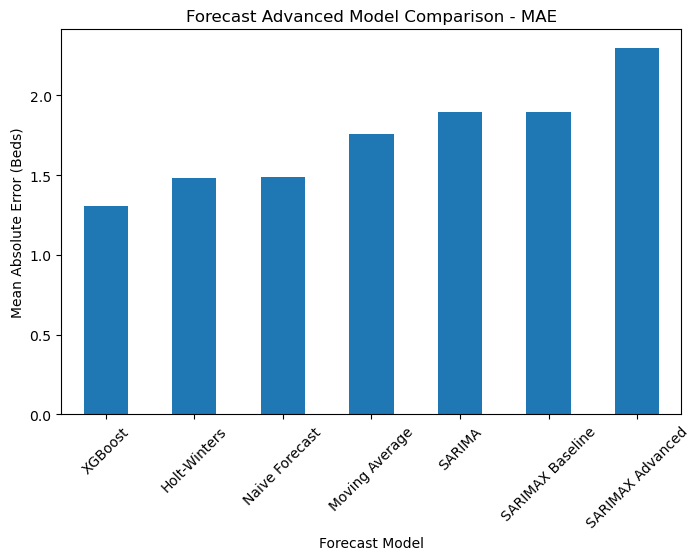

In [96]:
plt.figure(figsize=(8,5))
advanced_model_summary["MAE"].plot(kind="bar")
plt.title("Forecast Advanced Model Comparison - MAE")
plt.ylabel("Mean Absolute Error (Beds)")
plt.xlabel("Forecast Model")
plt.xticks(rotation=45)
plt.show()

    The advanced model evaluation showed that XGBoost substantially outperformed Advanced SARIMAX for 30-day hospital bed forecasting. XGBoost achieved the lowest overall error (MAE 1.30 vs 2.30; RMSE 1.66 vs 2.73) and delivered particularly strong results in Cardiology, Orthopaedics, and Day Case Units. While Advanced SARIMAX successfully incorporated operational and calendar factors, it struggled in highly variable wards such as ICU and Oncology. These findings indicate that XGBoost is the most suitable model for medium-term hospital bed demand forecasting across the Albion Care Network, providing the best balance of accuracy and operational usefulness for 7–30 day capacity planning

##### Comparison of all the baseline and advanced models

- Load the baseline results

In [97]:
naive_results = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Models\Baseline Models\Results\naive_forecasts.csv")
moving_average_results = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Models\Baseline Models\Results\moving_average_forecasts.csv")
holt_results = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Models\Baseline Models\Results\holt_forecasts.csv")
sarima_results = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Models\Baseline Models\Results\sarima_forecasts.csv")
sarimax_baseline_results = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Models\Baseline Models\Results\sarimax_forecasts.csv")


In [98]:
# Add model name to each result dataframe
naive_results["Model"] = "Naive Forecast"
moving_average_results["Model"] = "Moving Average"
holt_results["Model"] = "Holt-Winters"
sarima_results["Model"] = "SARIMA"
sarimax_baseline_results["Model"] = "SARIMAX Baseline"
xgb_results["Model"] = "XGBoost"
sarimax_advanced_results["Model"] = "SARIMAX Advanced"

# Combine all results
models_comparison = pd.concat([naive_results, moving_average_results, holt_results, sarima_results, sarimax_baseline_results, xgb_results, sarimax_advanced_results], ignore_index=True)

# Rearrange columns
models_comparison = model_comparison[["Model", "Unit", "MAE", "RMSE", "MAPE"]]

# Display comparison
models_comparison.head

<bound method NDFrame.head of                 Model                                Unit       MAE      RMSE  \
0      Naive Forecast          HHN-LON-02_Cardiology Ward  0.065476  0.093169   
1      Naive Forecast      HHN-BIR-01_Orthopaedics Ward A  0.083333  0.111359   
2      Naive Forecast      HHN-EDI-01_Orthopaedics Ward A  0.083333  0.097080   
3      Naive Forecast  HHN-BIR-01_General Medicine Ward A  0.101190  0.110240   
4      Naive Forecast  HHN-EDI-01_General Medicine Ward A  0.107143  0.117851   
..                ...                                 ...       ...       ...   
275  SARIMAX Advanced          HHN-LON-01_Cardiology Ward  4.320144  5.257046   
276  SARIMAX Advanced          HHN-EDI-01_Cardiology Ward  4.370665  4.775510   
277  SARIMAX Advanced      HHN-MAN-01_Orthopaedics Ward B  4.448138  5.422910   
278  SARIMAX Advanced                      HHN-LON-01_ICU  4.707481  5.030195   
279  SARIMAX Advanced            HHN-LON-01_Oncology Ward  4.849198  5.304412  

In [99]:
advanced_model_summary = (advanced_model_comparison.groupby("Model")[["MAE", "RMSE", "MAPE"]].mean().sort_values("MAE"))
advanced_model_summary

,MAE,RMSE,MAPE
Model,,,
XGBoost,1.304871,1.660864,7.690081e+12
Holt-Winters,1.483218,1.758004,3.128260e+13
Naive Forecast,1.486310,1.758487,2.881768e+13
Moving Average,1.760034,2.498412,2.738158e+13
SARIMA,1.898543,2.138187,2.996365e+13
SARIMAX Baseline,1.898543,2.138187,2.996365e+13
SARIMAX Advanced,2.299619,2.732724,2.389688e+13


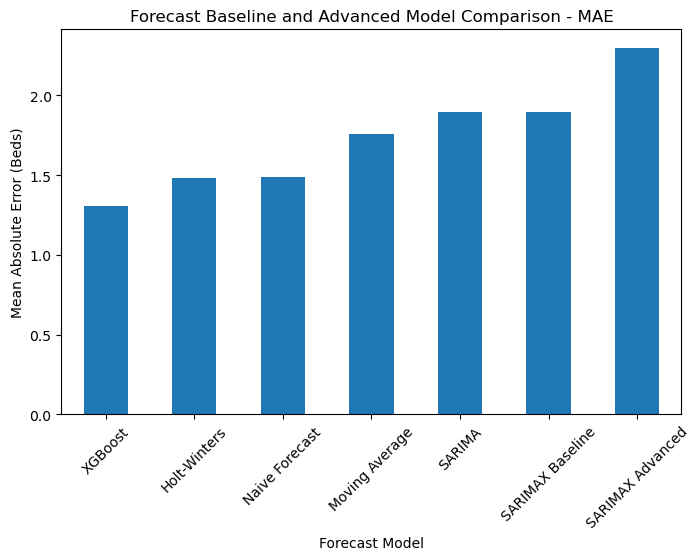

In [100]:
plt.figure(figsize=(8,5))
advanced_model_summary["MAE"].plot(kind="bar")
plt.title("Forecast Baseline and Advanced Model Comparison - MAE")
plt.ylabel("Mean Absolute Error (Beds)")
plt.xlabel("Forecast Model")
plt.xticks(rotation=45)
plt.show()

    XGBoost was the best-performing model overall, achieving the lowest forecasting errors with an average MAE of 1.305 and RMSE of 1.661. This indicates that it produced the most accurate medium-term (7–30 day) forecasts by effectively capturing complex and nonlinear occupancy patterns.
    Among the baseline models, Holt-Winters and the Naive Forecast delivered the strongest performance. Holt-Winters achieved the lowest baseline error (MAE = 1.483, RMSE = 1.758), with the Naive Forecast performing almost identically (MAE = 1.486, RMSE = 1.758). Their similar results suggest that hospital bed occupancy exhibits strong persistence, where recent occupancy levels are often good predictors of short-term demand.
    The Moving Average model ranked fourth (MAE = 1.760, RMSE = 2.498). While smoothing reduced short-term fluctuations, it also removed important changes in occupancy, leading to lower forecasting accuracy than Holt-Winters and the Naive Forecast.
    Baseline SARIMA and Baseline SARIMAX produced identical results (MAE = 1.899, RMSE = 2.138), indicating that adding the selected external variables in the baseline SARIMAX configuration did not improve forecasting performance.
    Advanced SARIMAX recorded the highest forecasting errors (MAE = 2.300, RMSE = 2.733), making it the weakest-performing model in this evaluation. Although it incorporated additional operational and calendar-based features, its chosen configuration did not generalise well across all hospital wards.

##### Save the advanced models

In [101]:
advanced_model_comparison.to_csv("../Models/Advanced Models/Results/advanced_model_comparison.csv", index=False)
